# Coffee, Git, and Snakemake: a tiny chemistry-flavored onboarding notebook

Welcome. Let's get some deep dive into the following:
- terminal basics
- Git and GitHub workflow
- VS Code
- conda environments
- Jupyter notebooks
- a tiny Snakemake workflow
- basic data analysis with `pandas` and `seaborn`

## Story
Your group is trying to answer a critical scientific question:

> **Who is most responsible for the lab's coffee depletion, and can we describe the team's caffeine profile reproducibly?**

## Part 1 — Terminal warm-up

Run these commands in the terminal, not in a Python cell. You can also use the integrated VS Code terminal. This might be easier for Windows users. 

```bash
pwd
ls
ls -la
cd data
ls
cd ..
head data/coffee_team.csv
```

Reflection:
- What is the difference between `pwd` and `ls`?
- What does `cd ..` do?

Now download this pretty image from the internet: https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRJQhohdI6fgAGwv4ZotFQJE1Q9OnqN7fKJIA&s and move it from the Downloads folder to the tutorial folder using only the command line!

## Part 2 — Conda environment check

```bash
conda env list
conda activate chem-coffee-tutorial
python --version
which python
python -c "import pandas, seaborn; print('Packages imported successfully!')"
```

Why do we care about environments?

## Part 3 — Read the data in Python

In [1]:
import pandas as pd

df = pd.read_csv(
    "/Users/mpiejko/Desktop/TUM/problemsets/TutorialMayerLab/data/coffee_team.csv"
)
df

,name,cups_per_day,coffee_style,caffeine_mg_per_cup,descriptor_score,messiness_index,descriptors,estimated_daily_caffeine_mg
0,Milli,2,espresso,65,4.8,3,acidic;floral;lab-fuel,130
1,Natalia,1000,filter,180,3.2,2,sugary;calm;reproducible,1800
2,Felix,13,cold brew,240,5.1,4,smooth;overnight;chaotic-good,720
3,Stefan,-2,cappuccino,120,4.1,3,milky;balanced;peer-reviewed,240
4,Nat,-4,espresso,65,6.0,5,intense;deadline;instrument-time,260
5,Robert,0,tea (suspiciously not coffee),35,2.0,1,herbal;control-sample;controversial,35
6,Max,3,filter,180,3.8,2,chocolate;steady;kinetics,360


In [2]:
df.shape

(7, 8)

In [3]:
df.dtypes

name                               str
cups_per_day                     int64
coffee_style                       str
caffeine_mg_per_cup              int64
descriptor_score               float64
messiness_index                  int64
descriptors                        str
estimated_daily_caffeine_mg      int64
dtype: object

## Part 4 — First quick analysis

In [6]:
df["estimated_daily_caffeine_mg"].describe()

count       7.000000
mean      506.428571
std       610.469179
min        35.000000
25%       185.000000
50%       260.000000
75%       540.000000
max      1800.000000
Name: estimated_daily_caffeine_mg, dtype: float64

In [5]:
df.sort_values("estimated_daily_caffeine_mg", ascending=False)[
    ["name", "coffee_style", "estimated_daily_caffeine_mg", "descriptors"]
]

,name,coffee_style,estimated_daily_caffeine_mg,descriptors
1,Natalia,filter,1800,sugary;calm;reproducible
2,Felix,cold brew,720,smooth;overnight;chaotic-good
6,Max,filter,360,chocolate;steady;kinetics
4,Nat,espresso,260,intense;deadline;instrument-time
3,Stefan,cappuccino,240,milky;balanced;peer-reviewed
0,Milli,espresso,130,acidic;floral;lab-fuel
5,Robert,tea (suspiciously not coffee),35,herbal;control-sample;controversial


Create a new column called `mg_per_descriptor_point`:

```python
estimated_daily_caffeine_mg / descriptor_score
```

In [7]:
df["mg_per_descriptor_point"] = (
    df["estimated_daily_caffeine_mg"] / df["descriptor_score"]
)
df

,name,cups_per_day,coffee_style,caffeine_mg_per_cup,descriptor_score,messiness_index,descriptors,estimated_daily_caffeine_mg,mg_per_descriptor_point
0,Milli,2,espresso,65,4.8,3,acidic;floral;lab-fuel,130,27.083333
1,Natalia,1000,filter,180,3.2,2,sugary;calm;reproducible,1800,562.500000
2,Felix,13,cold brew,240,5.1,4,smooth;overnight;chaotic-good,720,141.176471
3,Stefan,-2,cappuccino,120,4.1,3,milky;balanced;peer-reviewed,240,58.536585
4,Nat,-4,espresso,65,6.0,5,intense;deadline;instrument-time,260,43.333333
5,Robert,0,tea (suspiciously not coffee),35,2.0,1,herbal;control-sample;controversial,35,17.500000
6,Max,3,filter,180,3.8,2,chocolate;steady;kinetics,360,94.736842


## Part 5 — Seaborn for nicer plots

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.facecolor"] = "white"

you now probably got an error about a package which is not installed. Thus, install it via the terminal using pip.

In [12]:
# 3D INTERACTIVE PLOT with Plotly
fig = go.Figure()

# Create custom colors for each coffee style
coffee_colors = {
    "espresso": "#8B0000",
    "filter": "#FCEF02",
    "cold brew": "#4169E1",
    "cappuccino": "#E800D8",
    "tea (suspiciously not coffee)": "#228B22",
}

for coffee_style in df["coffee_style"].unique():
    mask = df["coffee_style"] == coffee_style
    subset = df[mask]

    fig.add_trace(
        go.Scatter3d(
            x=subset["cups_per_day"],
            y=subset["estimated_daily_caffeine_mg"],
            z=subset["descriptor_score"],
            mode="markers+text",
            text=subset["name"],
            textposition="top center",
            marker=dict(
                size=subset["mg_per_descriptor_point"] * 2,
                color=coffee_colors.get(coffee_style, "#FF6B6B"),
                opacity=0.8,
                line=dict(width=2, color="white"),
            ),
            name=coffee_style,
            hovertemplate="<b>%{text}</b><br>"
            + "Cups/day: %{x}<br>"
            + "Caffeine (mg): %{y}<br>"
            + "Descriptor Score: %{z}<br>"
            + "<extra></extra>",
        )
    )

fig.update_layout(
    title=dict(
        text="<b>3D Coffee Profile: The Ultimate Lab Caffeine Map 🚀</b>",
        font=dict(size=20),
    ),
    scene=dict(
        xaxis_title="Cups per Day",
        yaxis_title="Daily Caffeine (mg)",
        zaxis_title="Descriptor Score",
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
    ),
    width=1000,
    height=800,
    hovermode="closest",
)

fig.show()

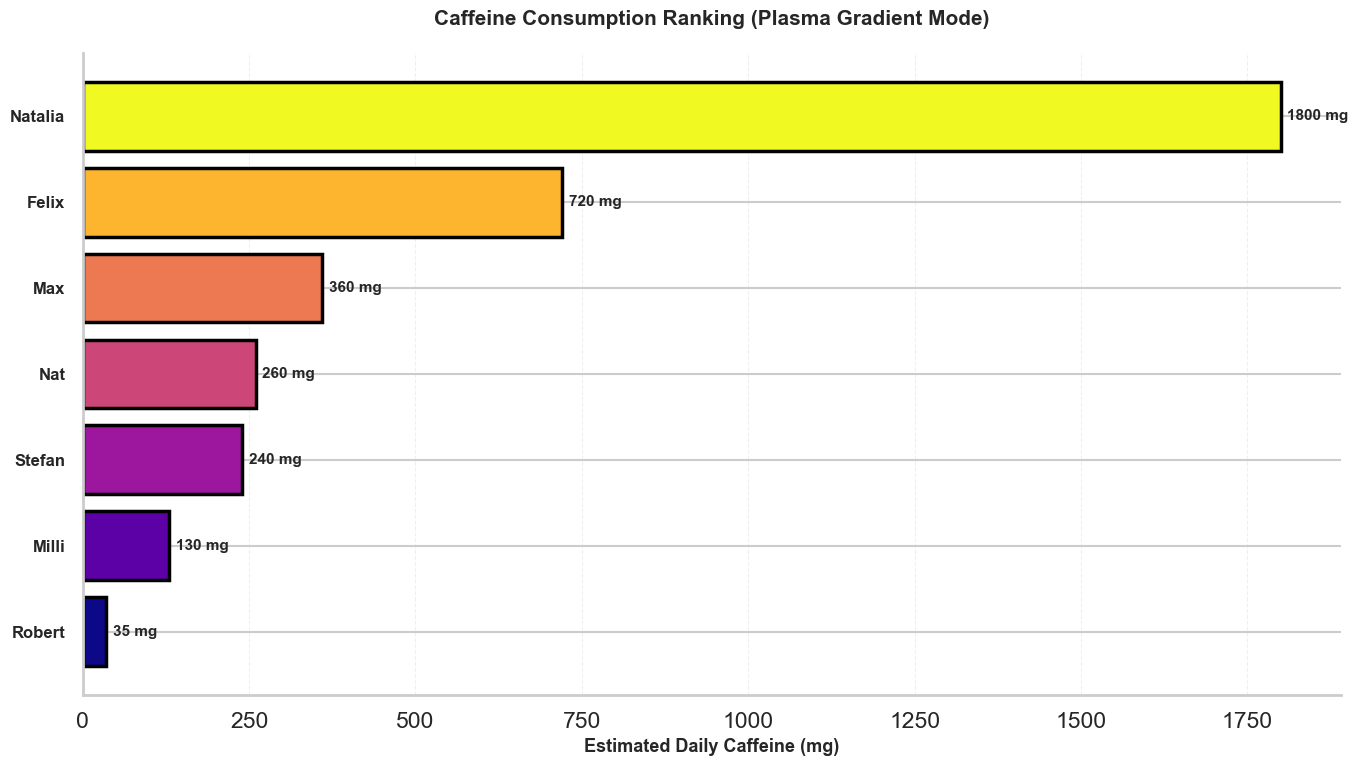

In [13]:
# FANCY PLASMA-GRADIENT PLOT with Seaborn + Matplotlib
fig, ax = plt.subplots(figsize=(14, 8))

# Sort by caffeine for better visualization
sorted_df = df.sort_values("estimated_daily_caffeine_mg", ascending=True)

# Create a numerical index for x-axis positioning
x_pos = np.arange(len(sorted_df))

# Create plasma color gradient based on caffeine level
colors = plt.cm.plasma(np.linspace(0, 1, len(sorted_df)))

# Create the fancy bar plot
bars = ax.barh(
    x_pos,
    sorted_df["estimated_daily_caffeine_mg"],
    color=colors,
    edgecolor="black",
    linewidth=2.5,
)

# Add value labels on the bars with better styling
for i, (idx, row) in enumerate(sorted_df.iterrows()):
    value = row["estimated_daily_caffeine_mg"]
    ax.text(
        value + 10, i, f"{value:.0f} mg", va="center", fontsize=11, fontweight="bold"
    )

# Customize the plot
ax.set_yticks(x_pos)
ax.set_yticklabels(sorted_df["name"], fontsize=12, fontweight="bold")
ax.set_xlabel("Estimated Daily Caffeine (mg)", fontsize=13, fontweight="bold")
ax.set_title(
    "Caffeine Consumption Ranking (Plasma Gradient Mode)",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

# Add a grid for better readability
ax.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.8)
ax.set_axisbelow(True)

# Style improvements
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

## Part 6 — group analysis

We define a silly "lab survival index":

```text
lab_survival_index = estimated_daily_caffeine_mg / (messiness_index + 1)
```

In [16]:
df["lab_survival_index"] = df["estimated_daily_caffeine_mg"] / (
    df["messiness_index"] + 1
)
df[["name", "lab_survival_index"]].sort_values("lab_survival_index", ascending=False)

,name,lab_survival_index
1,Natalia,600.000000
2,Felix,144.000000
6,Max,120.000000
3,Stefan,60.000000
4,Nat,43.333333
0,Milli,32.500000
5,Robert,17.500000


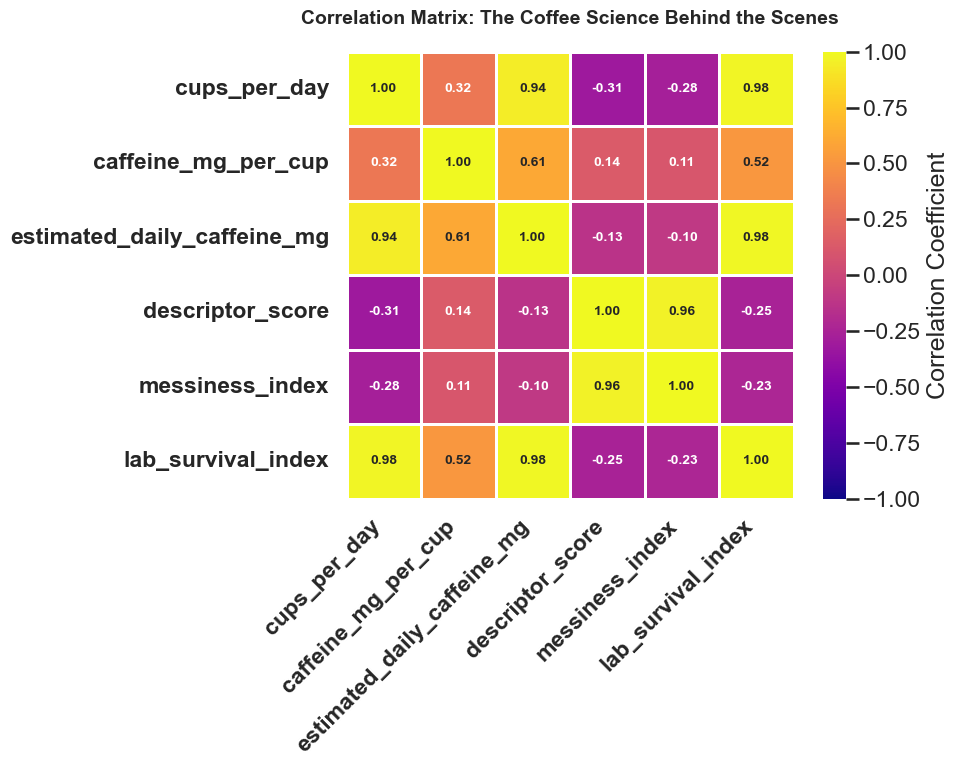

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))

# Select numeric columns for correlation
numeric_cols = df[
    [
        "cups_per_day",
        "caffeine_mg_per_cup",
        "estimated_daily_caffeine_mg",
        "descriptor_score",
        "messiness_index",
        "lab_survival_index",
    ]
].astype(float)

# Create correlation matrix
corr_matrix = numeric_cols.corr()

# Plot fancy heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="plasma",
    cbar_kws={"label": "Correlation Coefficient"},
    linewidths=2,
    linecolor="white",
    square=True,
    ax=ax,
    vmin=-1,
    vmax=1,
    cbar=True,
    annot_kws={"fontsize": 10, "fontweight": "bold"},
)

ax.set_title(
    "Correlation Matrix: The Coffee Science Behind the Scenes",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontweight="bold")
plt.yticks(rotation=0, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# INTERACTIVE BUBBLE CHART with Plotly
fig = px.scatter(
    df,
    x="cups_per_day",
    y="estimated_daily_caffeine_mg",
    size="descriptor_score",
    color="lab_survival_index",
    hover_name="name",
    hover_data={
        "cups_per_day": ":.1f",
        "estimated_daily_caffeine_mg": ":.0f",
        "descriptor_score": ":.2f",
        "lab_survival_index": ":.2f",
        "coffee_style": True,
        "messiness_index": ":.1f",
    },
    color_continuous_scale="Plasma",
    size_max=60,
    title="<b>Interactive Coffee Bubble Chart: Cups vs Caffeine (Plasma Gradient)</b>",
)

fig.update_layout(
    width=1000,
    height=700,
    font=dict(size=12),
    xaxis_title="Cups per Day",
    yaxis_title="Daily Caffeine (mg)",
    coloraxis_colorbar=dict(title="Lab Survival<br>Index"),
    hovermode="closest",
    plot_bgcolor="rgba(240, 240, 240, 0.5)",
    paper_bgcolor="white",
    showlegend=True,
)

fig.update_traces(marker=dict(line=dict(width=2, color="white")))
fig.show()

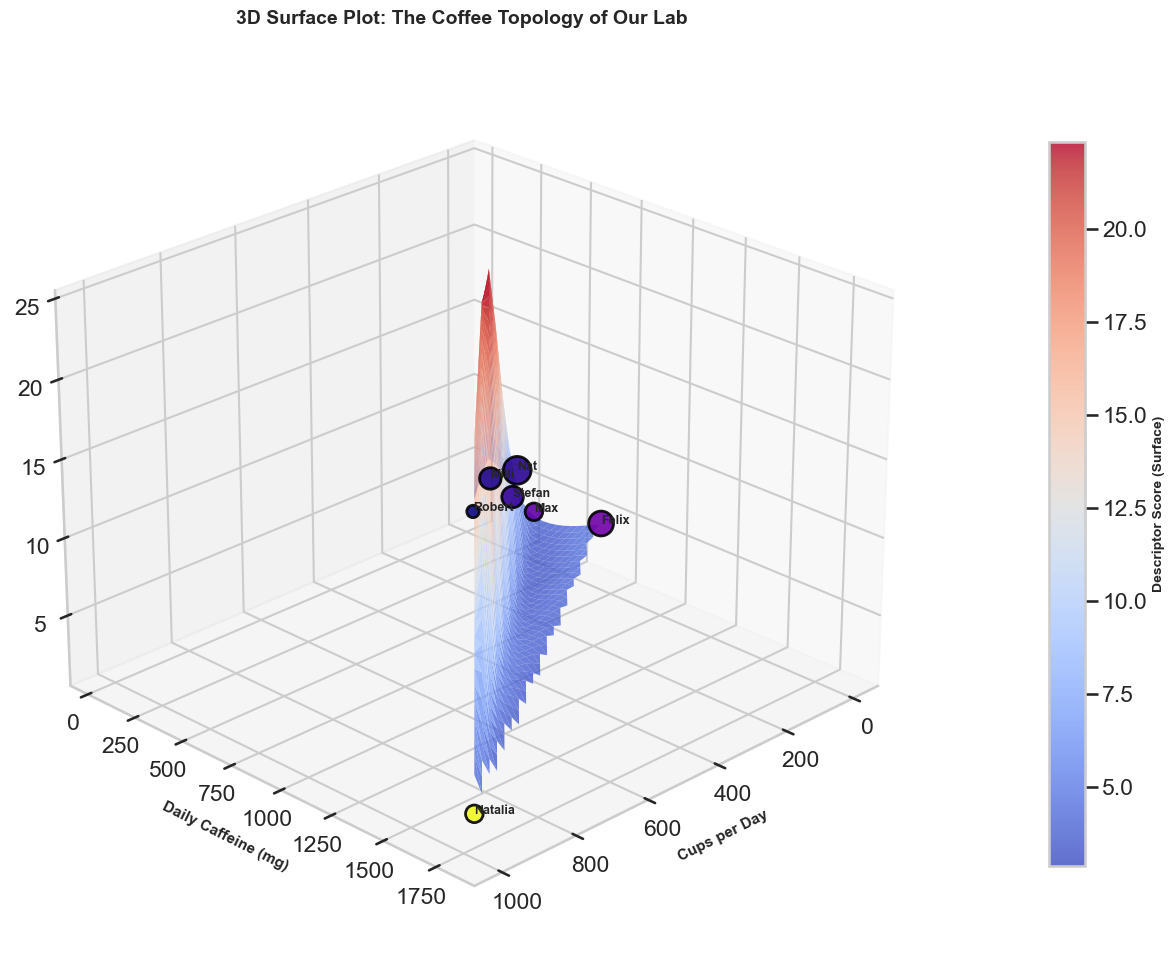

In [18]:
from scipy.interpolate import griddata

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Create a grid for the surface
x = df["cups_per_day"].values.astype(float)
y = df["estimated_daily_caffeine_mg"].values.astype(float)
z = df["descriptor_score"].values.astype(float)

# Create a finer grid for visualization
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate Z values
Zi = griddata((x, y), z, (Xi, Yi), method="cubic")

# Create the surface plot with fancy colormap
surf = ax.plot_surface(
    Xi,
    Yi,
    Zi,
    cmap="coolwarm",
    alpha=0.8,
    edgecolor="none",
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
)

# Scatter the actual data points on top
scatter = ax.scatter(
    x,
    y,
    z,
    c=df["lab_survival_index"],
    cmap="plasma",
    s=df["messiness_index"] * 80,
    edgecolors="black",
    linewidth=2,
    alpha=0.9,
)

# Add labels for each point
for idx, row in df.iterrows():
    ax.text(
        row["cups_per_day"],
        row["estimated_daily_caffeine_mg"],
        row["descriptor_score"],
        row["name"],
        fontsize=9,
        fontweight="bold",
    )

ax.set_xlabel("Cups per Day", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("Daily Caffeine (mg)", fontsize=11, fontweight="bold", labelpad=10)
ax.set_zlabel("Descriptor Score", fontsize=11, fontweight="bold", labelpad=10)
ax.set_title(
    "3D Surface Plot: The Coffee Topology of Our Lab",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Add colorbars
cbar1 = plt.colorbar(surf, ax=ax, pad=0.1, shrink=0.8)
cbar1.set_label("Descriptor Score (Surface)", fontsize=10, fontweight="bold")

ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

In [ ]:
# Set dark theme for dramatic effect
sns.set_theme(style="dark")

# Create the layered bivariate plot
f, ax = plt.subplots(figsize=(10, 8))

# Layer 1: Scatterplot with small dark points
sns.scatterplot(
    x=df["cups_per_day"],
    y=df["estimated_daily_caffeine_mg"],
    s=8,
    color=".15",
    alpha=0.6,
    ax=ax,
)

# Layer 2: 2D histogram with plasma colormap
sns.histplot(
    x=df["cups_per_day"],
    y=df["estimated_daily_caffeine_mg"],
    bins=30,
    pthresh=0.05,
    cmap="plasma",
    ax=ax,
    alpha=0.8,
)

# Layer 3: KDE density contours in white
sns.kdeplot(
    x=df["cups_per_day"],
    y=df["estimated_daily_caffeine_mg"],
    levels=6,
    color="w",
    linewidths=2,
    ax=ax,
)

# Add team member labels for the outliers
for idx, row in df.iterrows():
    if row["estimated_daily_caffeine_mg"] > 300:  # Label high caffeine consumers
        ax.annotate(
            row["name"],
            (row["cups_per_day"], row["estimated_daily_caffeine_mg"]),
            xytext=(10, 10),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8),
        )

# Customize the plot
ax.set_xlabel("Cups per Day", fontsize=12, fontweight="bold")
ax.set_ylabel("Estimated Daily Caffeine (mg)", fontsize=12, fontweight="bold")
ax.set_title(
    "Bivariate Coffee Analysis: Cups vs Caffeine (Plasma Mode)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

## Part 7 — What is Snakemake?

Snakemake is a python-based workflow manager that automatically creates directed acyclic graphs only depending on inputs and outputs. This makes it extremely powerful for larger workflows which you still want to be modular or which you want to extend on the go. We will only have a really short intro today, but if you are interested the documentation is really good and at least now you know it exists!

In this repository:

- input: `data/coffee_team.csv`
- script: `scripts/analyze_coffee.py`
- workflow file: `Snakefile`
- outputs:
  - `results/coffee_summary.csv`
  - `results/top_consumer.txt`

Inspect the workflow in the terminal:

```bash
cat Snakefile
cat scripts/analyze_coffee.py
```

## Part 8 — Run the workflow from the terminal

```bash
snakemake -np
snakemake -p --cores 1
ls results
cat results/top_consumer.txt
```

## Part 9 — Git practice

```bash
git status
git add data/coffee_team.csv results/coffee_summary.csv results/top_consumer.txt notebooks/01_coffee_git_snakemake_tutorial.ipynb
git commit -m "Add new coffee profile and rerun Snakemake workflow"
git push
```

## Part 10 — Tiny package-structure preview

Today, a plain script in `scripts/` is enough. In larger projects, you often grow into something like:

```text
my_project/
├── data/
├── notebooks/
├── scripts/
└── my_project/
    ├── __init__.py
    └── utils.py
```

This makes your python code actually usable by other people or even installable if you have a real python package.

## Bonus ideas

- add tea or mate as a second dataset
- add a config file
- add a second Snakemake rule that makes plots automatically